# Лабораторная работа № 3.3 — Метод наименьших квадратов

Вариант 6. Запускай ячейки сверху вниз. Все исходные данные заданы в ноутбуке, поэтому его можно открыть отдельно от файлов input.txt и output.txt.

Подбираем многочлены первой и второй степеней, минимизируя сумму квадратов отклонений от табличных значений.

## Исходные данные

Числа ниже соответствуют файлу input.txt этой работы.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import List

rows = [[-3.0, -2.0, -1.0, 0.0, 1.0, 2.0], [0.04979, 0.13534, 0.36788, 1.0, 2.7183, 7.3891]]
xs, ys = rows
print('Узлы:', xs, '\nЗначения:', ys)

Узлы: [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0] 
Значения: [0.04979, 0.13534, 0.36788, 1.0, 2.7183, 7.3891]


## Нормальные уравнения

Суммы степеней x образуют матрицу нормальной системы; решаем её через LU-разложение и получаем коэффициенты многочлена.

In [2]:
def LU_decompose(A):
    n = len(A)
    # lower
    L = [[0 for _ in range(n)] for _ in range(n)]
    # upper
    U = [row[:] for row in A]

    for k in range(1, n):
        for i in range(k - 1, n):
            for j in range(i, n):
                L[j][i] = U[j][i] / U[i][i]

        for i in range(k, n):
            for j in range(k - 1, n):
                U[i][j] = U[i][j] - L[i][k - 1] * U[k - 1][j]

    return L, U


def solve_system(L, U, b):
    # L * y = b
    n = len(L)
    y = [0 for _ in range(n)]
    for i in range(n):
        s = 0
        for j in range(i):
            s += L[i][j] * y[j]
        y[i] = (b[i] - s) / L[i][i]

    # U * x = y
    x = [0 for _ in range(n)]
    for i in range(n - 1, -1, -1):
        s = 0
        for j in range(n - 1, i - 1, -1):
            s += U[i][j] * x[j]
        x[i] = (y[i] - s) / U[i][i]
    return x


def least_squares(x, y, n):
    assert len(x) == len(y)
    A = []
    b = []
    for k in range(n + 1):
        A.append([sum(map(lambda x: x ** (i + k), x)) for i in range(n + 1)])
        b.append(sum(map(lambda x: x[0] * x[1] ** k, zip(y, x))))
    L, U = LU_decompose(A)
    return solve_system(L, U, b)


def P(coefs, x):
    return sum([c * x**i for i, c in enumerate(coefs)])


def sum_squared_errors(x, y, ls_coefs):
    y_ls = [P(ls_coefs, x_i) for x_i in x]
    return sum((y_i - y_ls_i)**2 for y_i, y_ls_i in zip(y, y_ls))

In [3]:
a1 = least_squares(xs, ys, 1)
a2 = least_squares(xs, ys, 2)
e1 = sum_squared_errors(xs, ys, a1)
e2 = sum_squared_errors(xs, ys, a2)
print('Степень 1:', a1, 'сумма квадратов:', e1)
print('Степень 2:', a2, 'сумма квадратов:', e2)

Степень 1: [2.5873666666666666, 1.28793] сумма квадратов: 11.454860640333331
Степень 2: [1.212638571428572, 1.8034530357142857, 0.5155230357142856] сумма квадратов: 1.5330046271892857


## График

График показывает результат вычисления на тех же исходных данных.

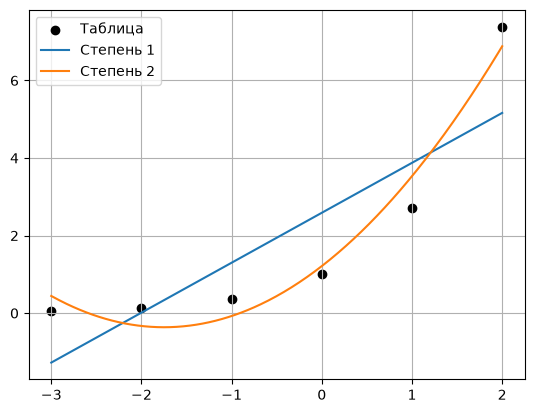

In [4]:
grid = np.linspace(min(xs), max(xs), 350)
plt.scatter(xs, ys, color='black', label='Таблица')
plt.plot(grid, [P(a1, t) for t in grid], label='Степень 1')
plt.plot(grid, [P(a2, t) for t in grid], label='Степень 2')
plt.grid(True)
plt.legend()
plt.show()

## Самопроверка

Как убедиться, что многочлен второй степени точнее на этих данных?

In [5]:
assert e2 < e1
assert np.allclose(a1, np.polynomial.polynomial.polyfit(xs, ys, 1))
assert np.allclose(a2, np.polynomial.polynomial.polyfit(xs, ys, 2))
print('Отношение ошибок:', e1/e2)

Отношение ошибок: 7.4721631214743605
